# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
411,6,20,"(0.46, 0.6)","(-0.05, -0.395, 0.005, 0.614)",0,1.0,"(-0.058, -0.592, 0.018, 0.947)",1.0,1.0,"(-0.07, -0.396, 0.037, 0.623)"
1277,19,54,"(0.03, 0.4)","(0.003, 0.219, -0.145, -0.768)",0,1.0,"(0.008, 0.024, -0.161, -0.478)",1.0,1.0,"(0.008, 0.223, -0.17, -0.881)"
914,31,39,"(0.23, 1.5)","(0.068, 0.198, -0.122, -0.301)",1,1.0,"(0.072, 0.386, -0.128, -0.422)",1.0,1.0,"(0.079, 0.573, -0.136, -0.543)"
124,12,5,"(0.66, 0.7)","(-0.002, 0.022, 0.082, 0.178)",1,1.0,"(-0.002, 0.218, 0.085, -0.142)",1.0,1.0,"(0.002, 0.414, 0.082, -0.461)"
1369,1,59,"(0.36, 0.2)","(0.009, -0.189, -0.039, 0.853)",0,1.0,"(0.006, -0.41, -0.021, 1.718)",1.0,1.0,"(-0.003, -0.186, 0.013, 0.794)"
...,...,...,...,...,...,...,...,...,...,...
631,19,28,"(0.1, 1.0)","(-0.022, -0.53, 0.074, 0.465)",1,1.0,"(-0.033, -0.342, 0.084, 0.331)",1.0,1.0,"(-0.04, -0.154, 0.09, 0.198)"
1963,25,83,"(0.79, 1.8)","(0.096, -0.224, -0.141, -0.104)",0,1.0,"(0.092, -0.411, -0.143, 0.031)",1.0,1.0,"(0.084, -0.221, -0.142, -0.152)"
1063,7,46,"(0.7, 0.2)","(0.05, 0.223, -0.122, -1.852)",0,1.0,"(0.055, -0.009, -0.159, -0.741)",1.0,1.0,"(0.054, 0.239, -0.174, -2.218)"
26,9,1,"(0.99, 0.1)","(0.001, -0.304, -0.013, 3.724)",1,1.0,"(-0.005, 0.07, 0.061, -0.526)",0.0,1.0,"(-0.003, -0.312, 0.051, 3.904)"


In [3]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.5)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,1.019947,"[0.008051806129515171, 0.5297757983207703, 0.0...",2.700407,0.632372
1,1,1.019965,"[0.00791929755359888, 0.5227949023246765, 0.04...",2.687009,0.633501
2,2,1.019980,"[0.007791309617459774, 0.5158681869506836, 0.0...",2.673731,0.634681
3,3,1.019994,"[0.0076706288382411, 0.5089931488037109, 0.040...",2.660577,0.635918
4,4,1.020007,"[0.007557577919214964, 0.5021694302558899, 0.0...",2.647547,0.637199


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
411,6,20,"(0.46, 0.6)","(-0.05, -0.395, 0.005, 0.614)",0,1.0,"(-0.058, -0.592, 0.018, 0.947)",1.0,1.0,"(-0.07, -0.396, 0.037, 0.623)"
1277,19,54,"(0.03, 0.4)","(0.003, 0.219, -0.145, -0.768)",0,1.0,"(0.008, 0.024, -0.161, -0.478)",1.0,1.0,"(0.008, 0.223, -0.17, -0.881)"
914,31,39,"(0.23, 1.5)","(0.068, 0.198, -0.122, -0.301)",1,1.0,"(0.072, 0.386, -0.128, -0.422)",1.0,1.0,"(0.079, 0.573, -0.136, -0.543)"
124,12,5,"(0.66, 0.7)","(-0.002, 0.022, 0.082, 0.178)",1,1.0,"(-0.002, 0.218, 0.085, -0.142)",1.0,1.0,"(0.002, 0.414, 0.082, -0.461)"
1369,1,59,"(0.36, 0.2)","(0.009, -0.189, -0.039, 0.853)",0,1.0,"(0.006, -0.41, -0.021, 1.718)",1.0,1.0,"(-0.003, -0.186, 0.013, 0.794)"


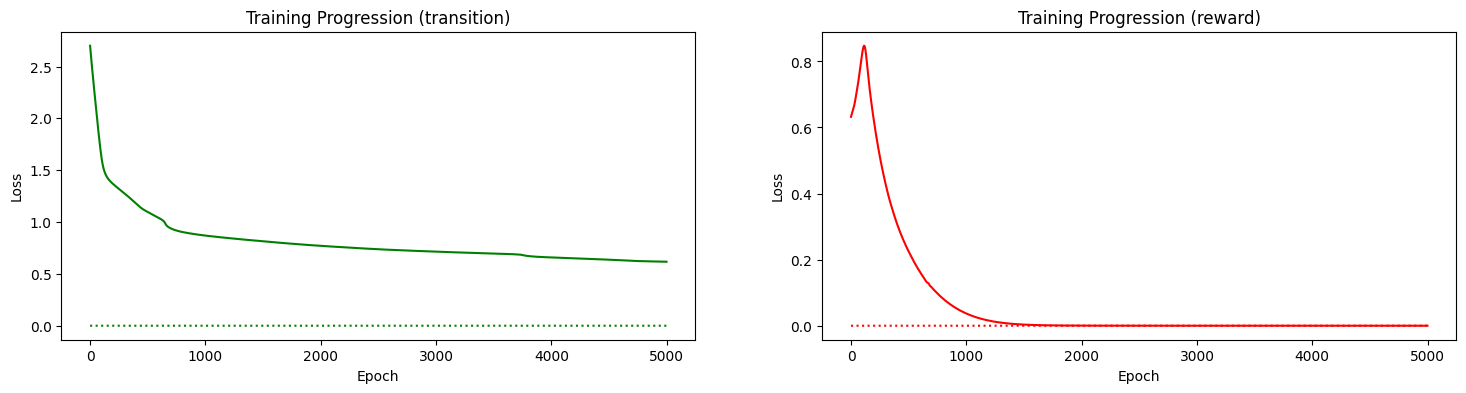

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

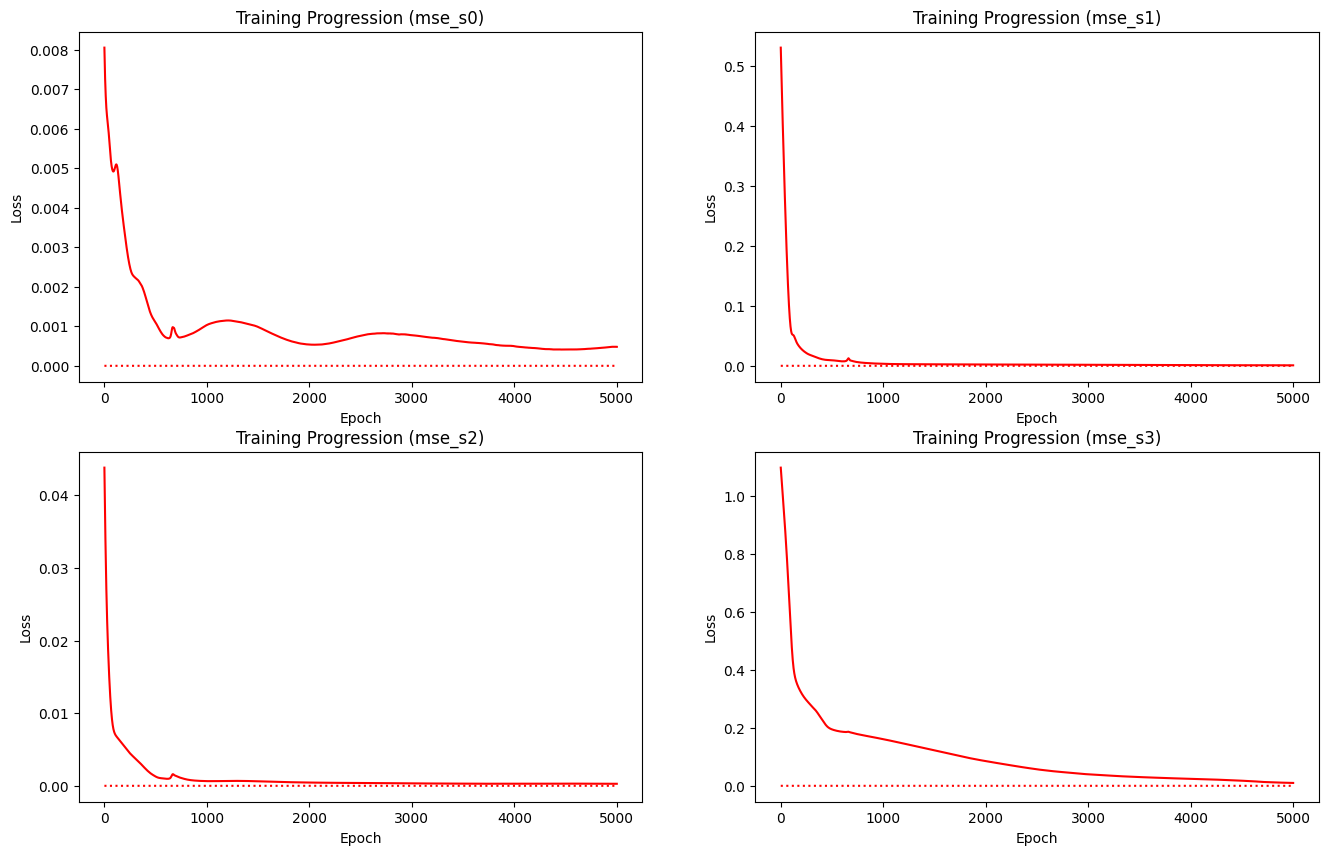

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    # 'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    # 'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

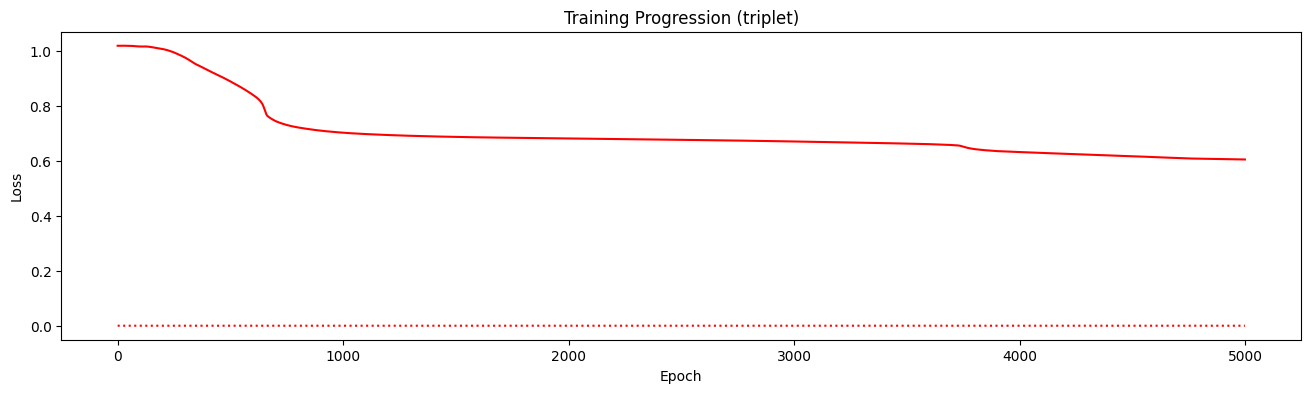

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

## Params

In [10]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_6241/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.46,0.6,0.35,1.8,0.347707,0.751762,0.0
1,499,0.03,0.4,0.23,1.3,0.181029,0.643959,1.0
2,499,0.23,1.5,0.33,1.0,-0.358148,0.165496,2.0
3,499,0.66,0.7,0.10,1.4,-0.230921,0.354409,3.0
4,499,0.36,0.2,0.03,0.9,0.287118,0.098594,4.0


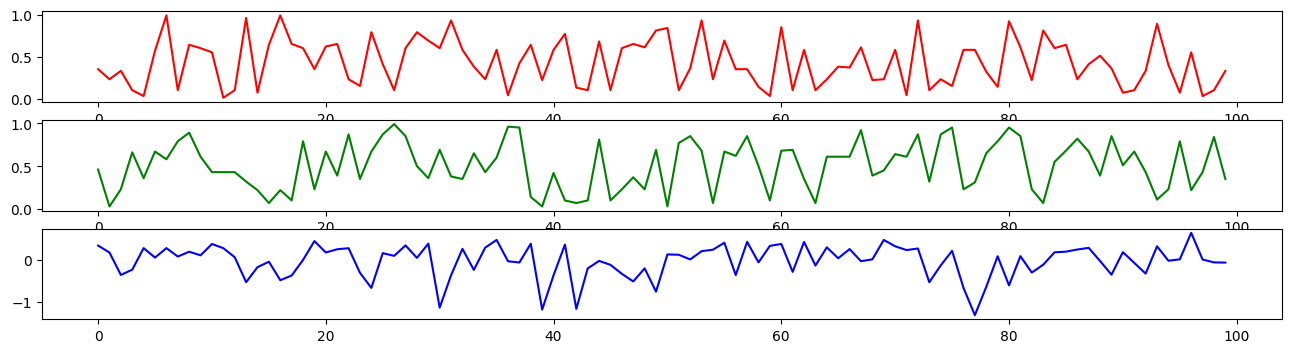

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

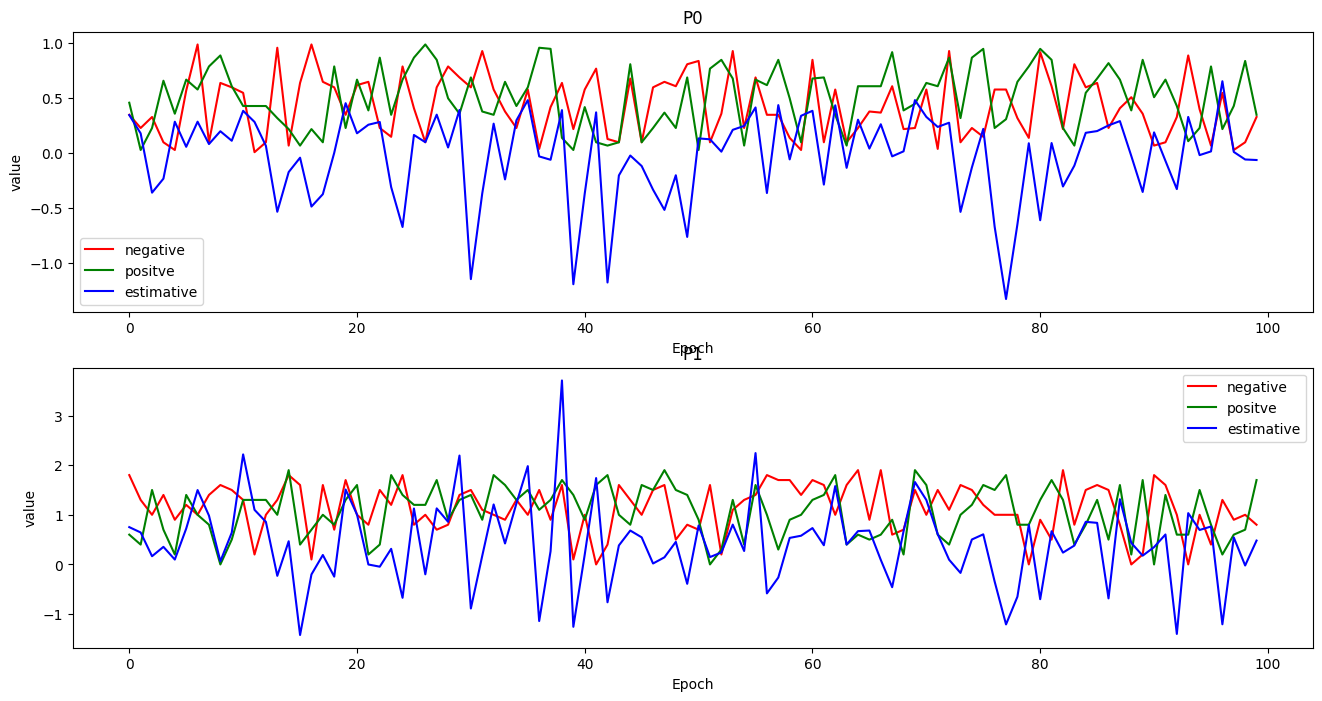

In [12]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [13]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.58, 1.0)","(0.02, -0.037, -0.022, 0.009)",0,1.0,"(0.019, -0.229, -0.022, 0.229)",0.0,1.0,"(0.015, -0.421, -0.017, 0.449)",...,0.438,0.58,1.0,0.542,1.054,0.005,0.001,0.004,0.011,0.0
1,1,0,"(0.58, 1.0)","(0.019, -0.229, -0.022, 0.229)",0,1.0,"(0.015, -0.421, -0.017, 0.449)",0.0,1.0,"(0.006, -0.612, -0.008, 0.671)",...,0.712,0.58,1.0,0.479,0.488,0.004,0.001,0.007,0.041,0.0
2,2,0,"(0.58, 1.0)","(0.015, -0.421, -0.017, 0.449)",0,1.0,"(0.006, -0.612, -0.008, 0.671)",0.0,1.0,"(-0.006, -0.804, 0.005, 0.894)",...,0.915,0.58,1.0,0.458,0.874,0.014,0.007,0.017,0.021,0.0
3,3,0,"(0.58, 1.0)","(0.006, -0.612, -0.008, 0.671)",0,1.0,"(-0.006, -0.804, 0.005, 0.894)",1.0,1.0,"(-0.022, -0.612, 0.023, 0.67)",...,0.659,0.58,1.0,0.580,1.152,0.004,0.015,0.001,0.011,0.0
4,4,0,"(0.58, 1.0)","(-0.006, -0.804, 0.005, 0.894)",1,1.0,"(-0.022, -0.612, 0.023, 0.67)",1.0,1.0,"(-0.034, -0.421, 0.036, 0.45)",...,0.405,0.58,1.0,0.630,0.315,0.006,0.014,0.003,0.045,0.0


In [14]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([71, 83, 74]) worst_episodes=array([34,  1, 75])


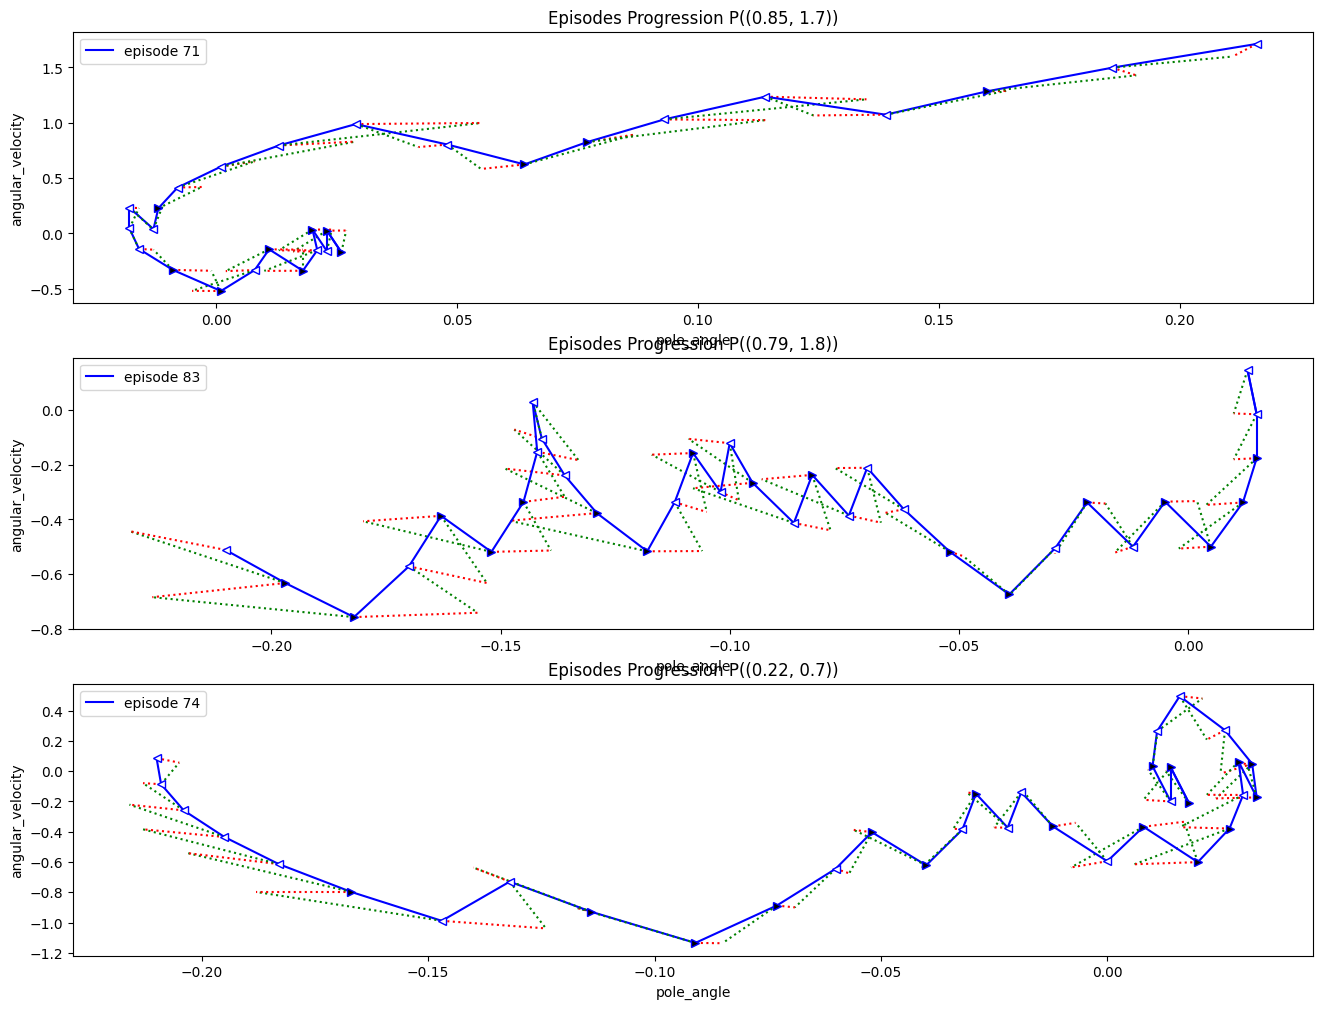

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

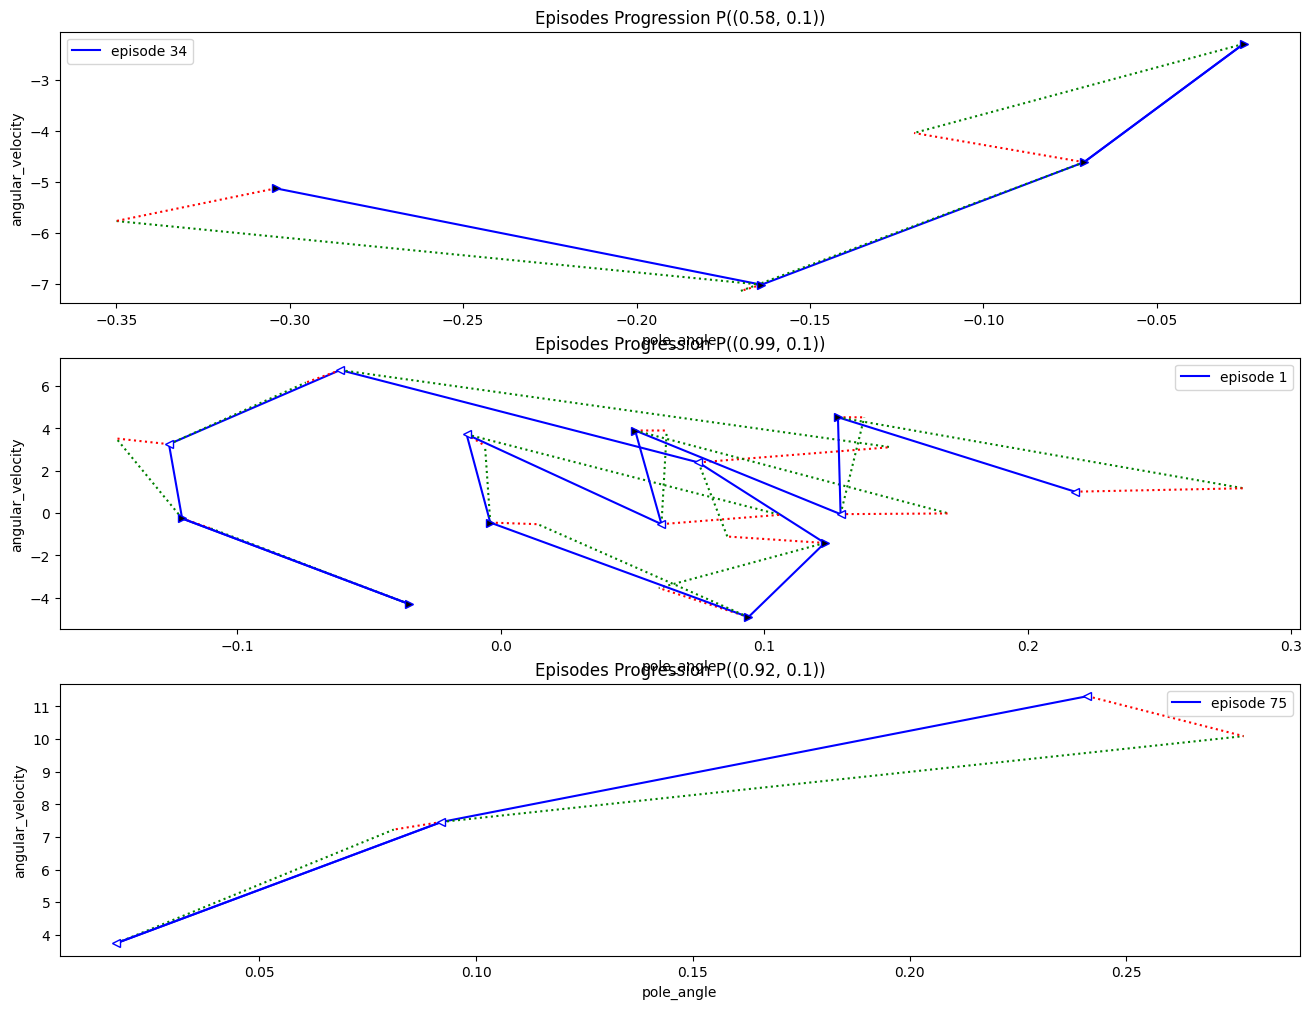

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

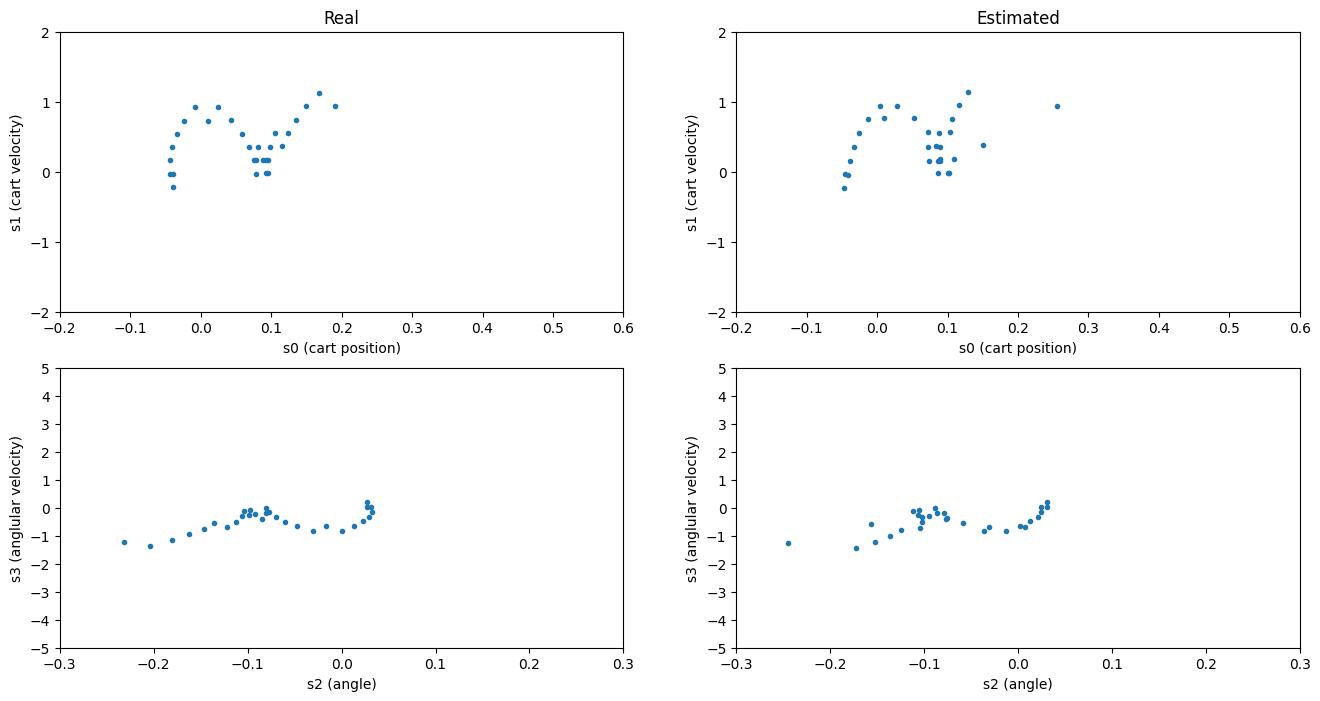

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

df = results.loc[results.episode == 3]

axs[0][0].scatter(x=df['s0'], y=df['s1'], marker='.')
axs[1][0].scatter(x=df['s2'], y=df['s3'], marker='.')

axs[0][1].scatter(x=df['estimated_s0'], y=df['estimated_s1'], marker='.')
axs[1][1].scatter(x=df['estimated_s2'], y=df['estimated_s3'], marker='.')

axs[0][0].set_title('Real')
axs[0][1].set_title('Estimated')

for i, _ in enumerate(axs[0]):
    axs[0][i].set_ylabel('s1 (cart velocity)')
    axs[0][i].set_xlabel('s0 (cart position)')
    axs[0][i].set_yticks(range(-2,3))
    axs[0][i].set_xticks([i/10 for i in range(-2,7)])

for i, _ in enumerate(axs[0]):
    axs[1][i].set_ylabel('s3 (anglular velocity)')
    axs[1][i].set_xlabel('s2 (angle)')
    axs[1][i].set_yticks(range(-5,6))
    axs[1][i].set_xticks([i/10 for i in range(-3,4)])

plt.show()

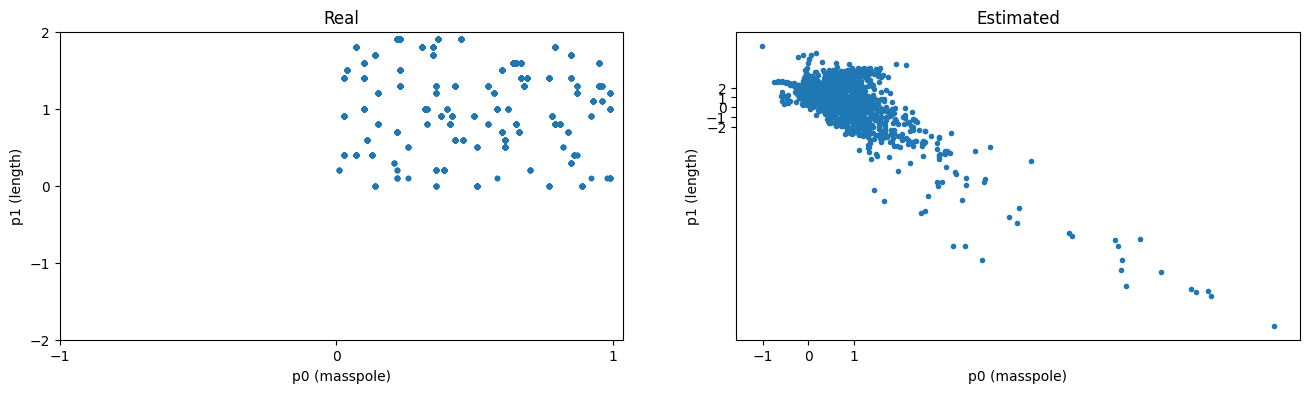

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# df = results.loc[results.episode == 3]
df = results

axs[0].scatter(x=df['p0'], y=df['p1'], marker='.')
axs[1].scatter(x=df['estimated_p0'], y=df['estimated_p1'], marker='.')

axs[0].set_title('Real')
axs[1].set_title('Estimated')

for i, ax in enumerate(axs):
    ax.set_ylabel(f'p1 {"(length)" if i==0 else ""}')
    ax.set_xlabel(f'p0 {"(masspole)" if i==0 else ""}')
    ax.set_yticks(range(-1,2))
    ax.set_xticks(range(-1,2))
    ax.set_ylim(-1,2)
    ax.set_xlim(-1,2)

plt.show()

In [19]:
from sklearn.cluster import KMeans
import numpy as np
X = df[['p0', 'p1']]
kmeans = KMeans(n_clusters=5, random_state=50, n_init="auto").fit(X)
kmeans.labels_
# kmeans.predict([[0, 0], [12, 3]])
# kmeans.cluster_centers_

array([3, 3, 3, ..., 1, 1, 1], dtype=int32)

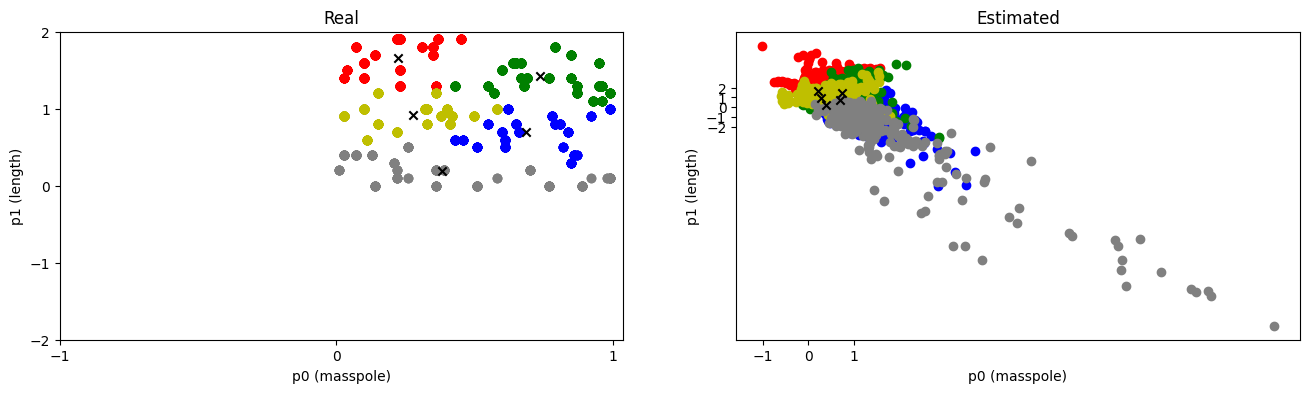

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

colors = ['r', 'b', 'g', 'y', 'gray']

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = X[kmeans.labels_ == label]
    axs[0].scatter(cluster_points['p0'], cluster_points['p1'], color=colors[i])
axs[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = df[kmeans.labels_ == label]
    axs[1].scatter(cluster_points['estimated_p0'], cluster_points['estimated_p1'], color=colors[i])
axs[1].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')


axs[0].set_title('Real')
axs[1].set_title('Estimated')

for i, ax in enumerate(axs):
    ax.set_ylabel(f'p1 {"(length)" if i==0 else ""}')
    ax.set_xlabel(f'p0 {"(masspole)" if i==0 else ""}')
    ax.set_yticks(range(-1,2))
    ax.set_xticks(range(-1,2))
    ax.set_ylim(-1,2)
    ax.set_xlim(-1,2)

plt.show()

# Evaluation

In [21]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.010,0.62,1.2,0.454,1.181,0.001,0.019,0.000,0.008,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.243,0.62,1.2,0.571,0.903,0.004,0.004,0.000,0.025,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.418,0.62,1.2,0.543,1.148,0.003,0.002,0.000,0.000,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.621,0.62,1.2,0.555,1.115,0.003,0.012,0.001,0.002,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.824,0.62,1.2,0.568,1.084,0.005,0.018,0.002,0.002,0.0


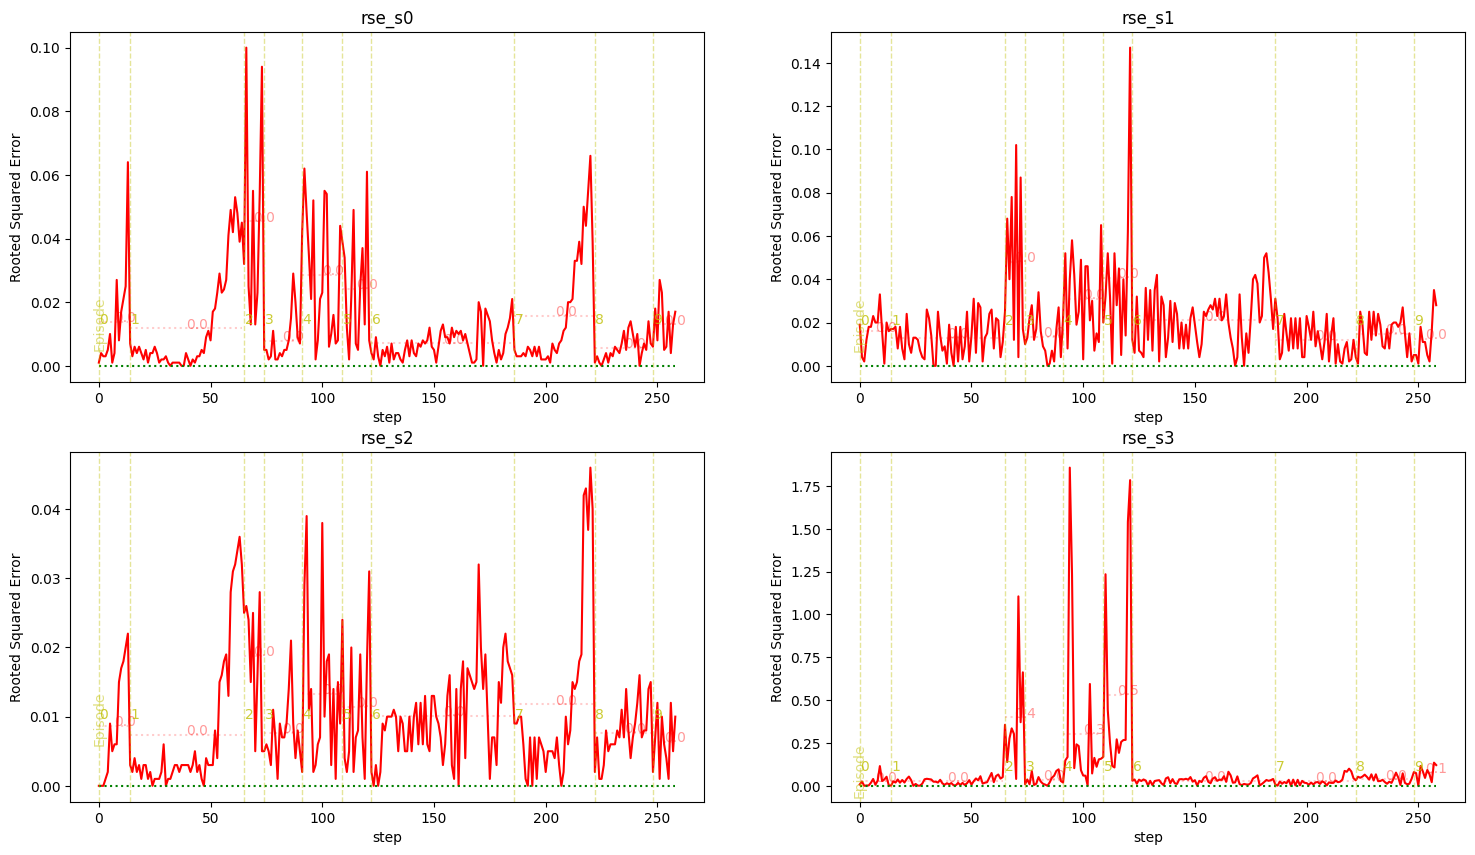

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

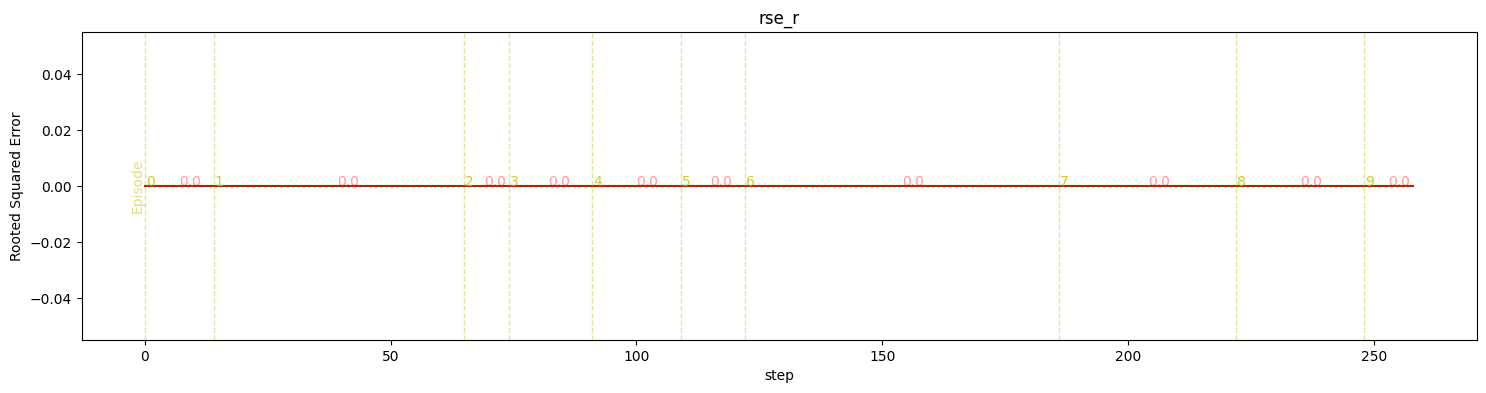

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

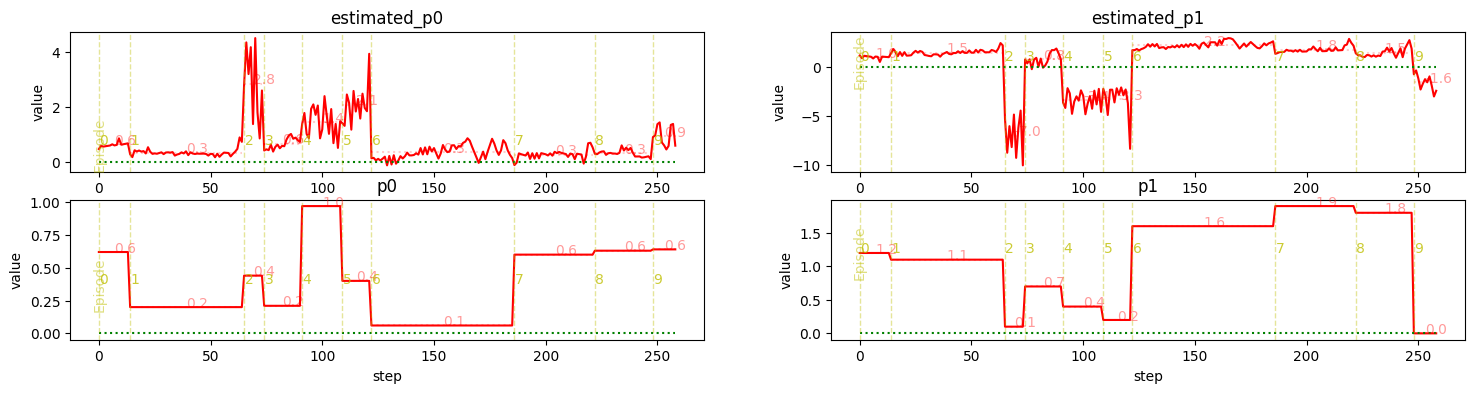

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

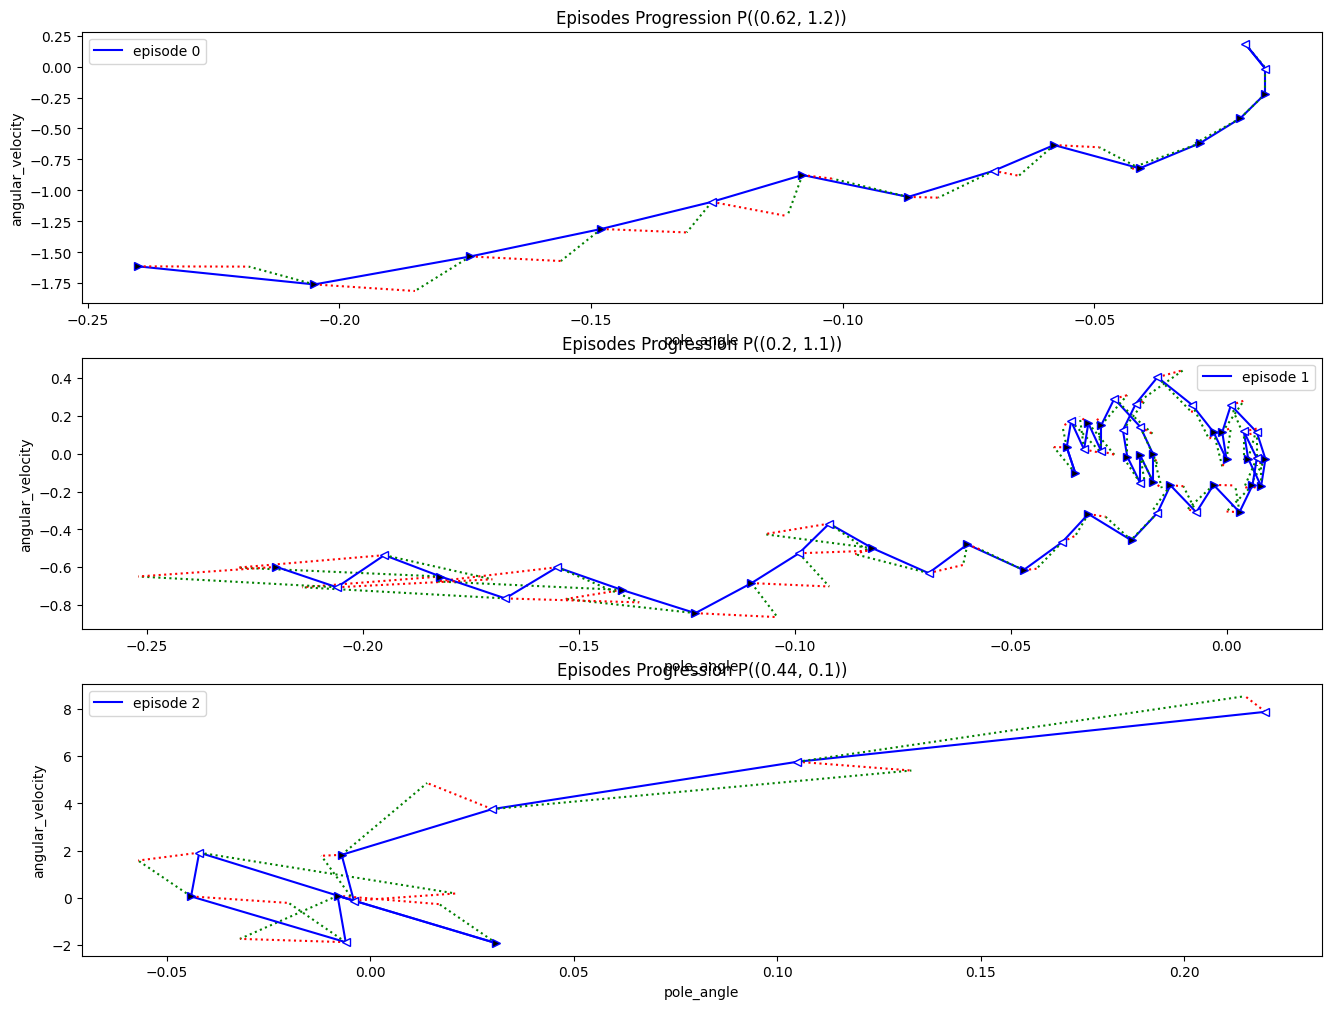

In [25]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()